# Life Expectancy & GDP Analysis
### World Health Organization & World Bank Data (2000–2015)

## Introduction
In this analysis we explore the relationship between GDP and life expectancy 
across six countries over 15 years. 

**Research Questions:**
- Is there a correlation between GDP and life expectancy?
- How have both metrics changed over time?
- Which countries show the strongest relationship?

**Countries:** Chile, China, Germany, Mexico, United States, Zimbabwe

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 150


## 1. Load and Inspecting Data

In [14]:
df = pd.read_csv('all_data.csv')
 
print(df.shape)
print(df.dtypes)
df.head(10)


(96, 4)
Country                              object
Year                                  int64
Life expectancy at birth (years)    float64
GDP                                 float64
dtype: object


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10
5,Chile,2005,78.4,1.229650e+11
6,Chile,2006,78.9,1.547880e+11
7,Chile,2007,78.9,1.736060e+11
8,Chile,2008,79.6,1.796380e+11
9,Chile,2009,79.3,1.723890e+11


## 2. Cleaning Data

In [15]:
print(df.isnull().sum())
 
df.columns = df.columns.str.strip()
df.rename(columns={
    'Life expectancy at birth (years)': 'life_expectancy',
    'GDP': 'gdp'
}, inplace=True)
 
print(df['Country'].unique())
print(df['Year'].min(), df['Year'].max())


Country                             0
Year                                0
Life expectancy at birth (years)    0
GDP                                 0
dtype: int64
['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
2000 2015


## 3. Summary Statistics

In [16]:
# Overall summary
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"Years covered: {df['Year'].min()} - {df['Year'].max()}")
print(f"Countries: {list(df['Country'].unique())}")
print()

# Summary stats
df[['life_expectancy', 'gdp']].describe().round(2)

=== Dataset Overview ===
Shape: (96, 4)
Years covered: 2000 - 2015
Countries: ['Chile', 'China', 'Germany', 'Mexico', 'United States of America', 'Zimbabwe']



,life_expectancy,gdp
count,96.00,9.600000e+01
mean,72.79,3.880499e+12
std,10.67,5.197561e+12
min,44.30,4.415703e+09
25%,74.47,1.733018e+11
50%,76.75,1.280220e+12
75%,78.90,4.067510e+12
max,81.00,1.810000e+13


### Observations made:
- The average life expectancy across all countries and years is 73 year (to the nearest year).
- GDP ranges between 4.4 billion and 18 trillion which can suggest major economic disparity between the nations analysed over the years.
- There are no null values, so no additions had to be made to the dataset.

## 4. Visualisations

### 4.1 Life Expectancy Over Time

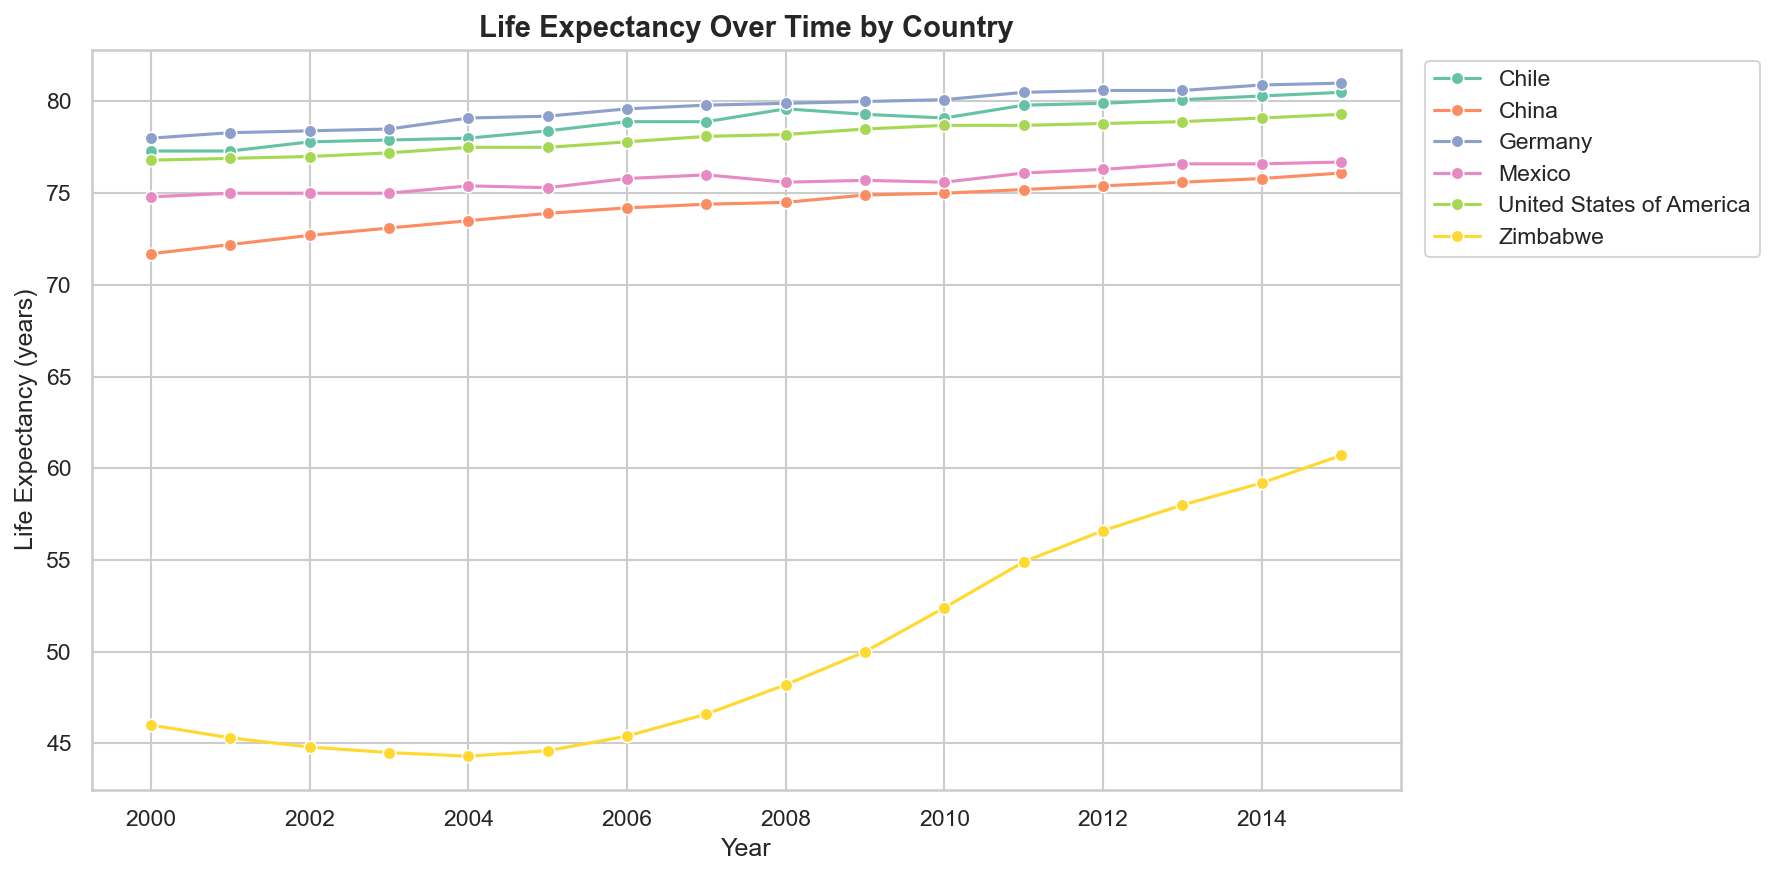

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='life_expectancy',
             hue='Country', marker='o', ax=ax)
ax.set_title('Life Expectancy Over Time by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/life_expectancy_over_time.png', bbox_inches='tight')
plt.show()

#### Insights Found:
- In **all 6 analysed nations** life expectancy has improved between 2000 and 2015.
- Zimbabwe showed the greatest improvement from the years 2005 to 2015 after a slight decline from 2000 due to having to recover from an HIV/AIDS crisis during the 1990s.
- The remaining 5 nations already started highly and have maintained slow improvement with Germany and Chile showing the highest life expectancies of the 6 nations.

### 4.2 GDP Over Time

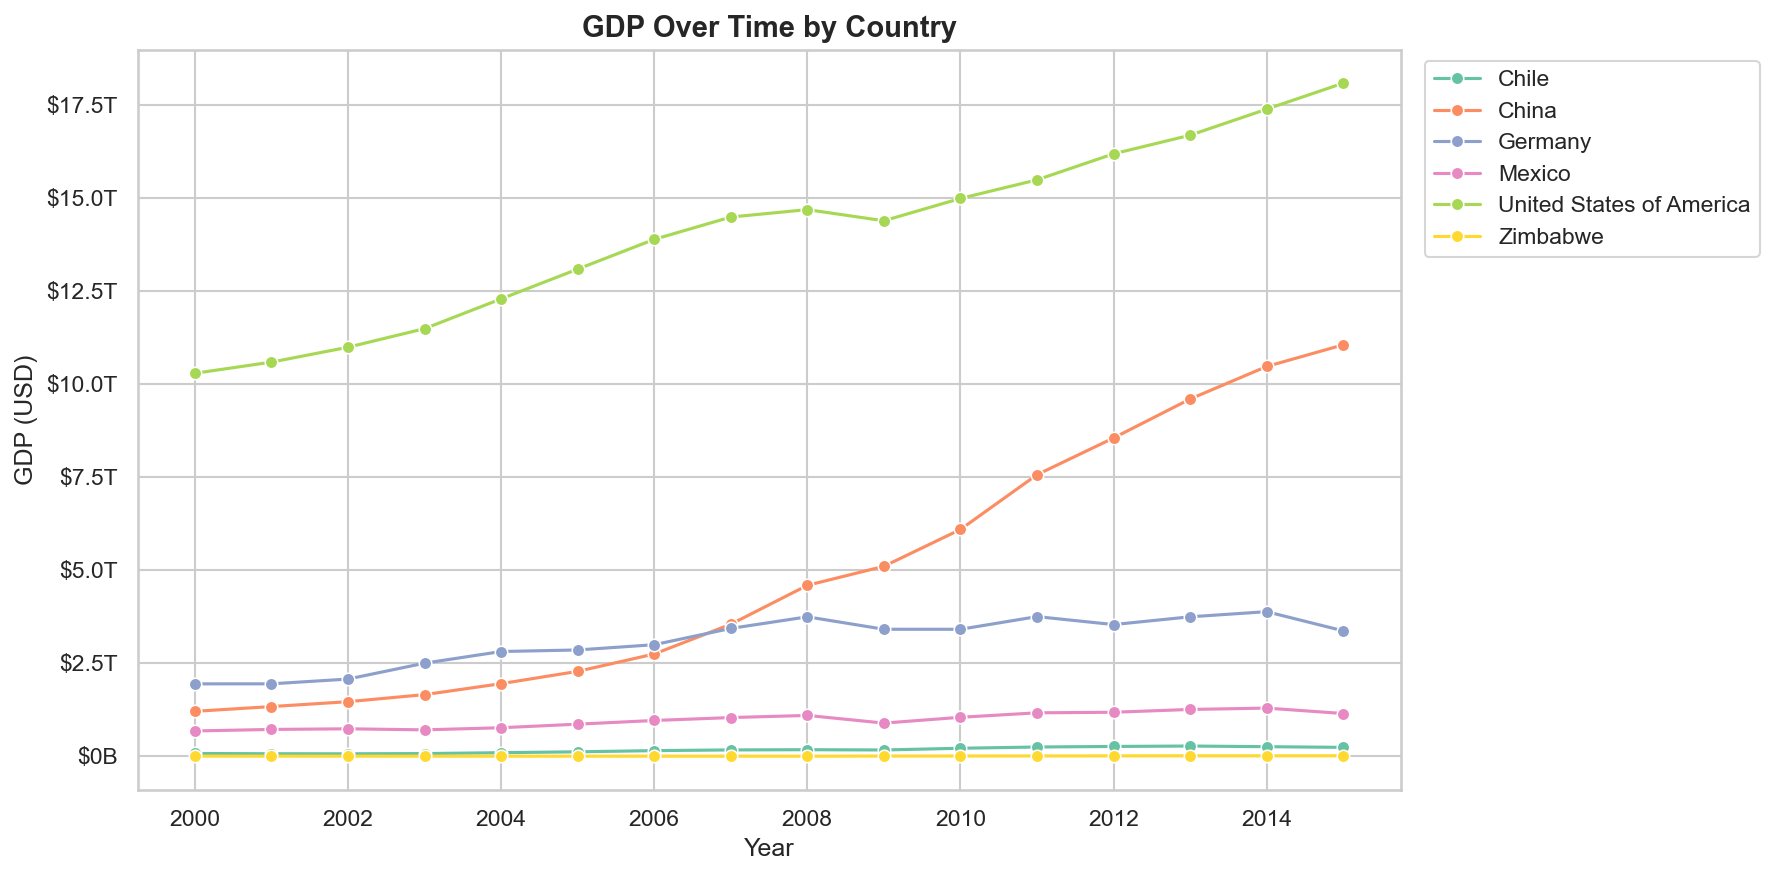

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='gdp',
             hue='Country', marker='o', ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'${x/1e12:.1f}T' if x >= 1e12 else f'${x/1e9:.0f}B'
))
ax.set_title('GDP Over Time by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('GDP (USD)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/gdp_over_time.png', bbox_inches='tight')
plt.show()

#### Insights Made
- GPD has increased in all 6 countries over the analysed period.
- The USA and China show far greater GDP values compared to the others which China showing the most improved GDP value.
- Zimbabwe and Chile have relatively low GDPs.
- The financial 'Panic of 2008' is noticeable in a majority of the nations observed with dips in GDP between 2008 and 2009. The only exception being China where GDP continued improving.

### 4.3 GDP vs Life Expectancy

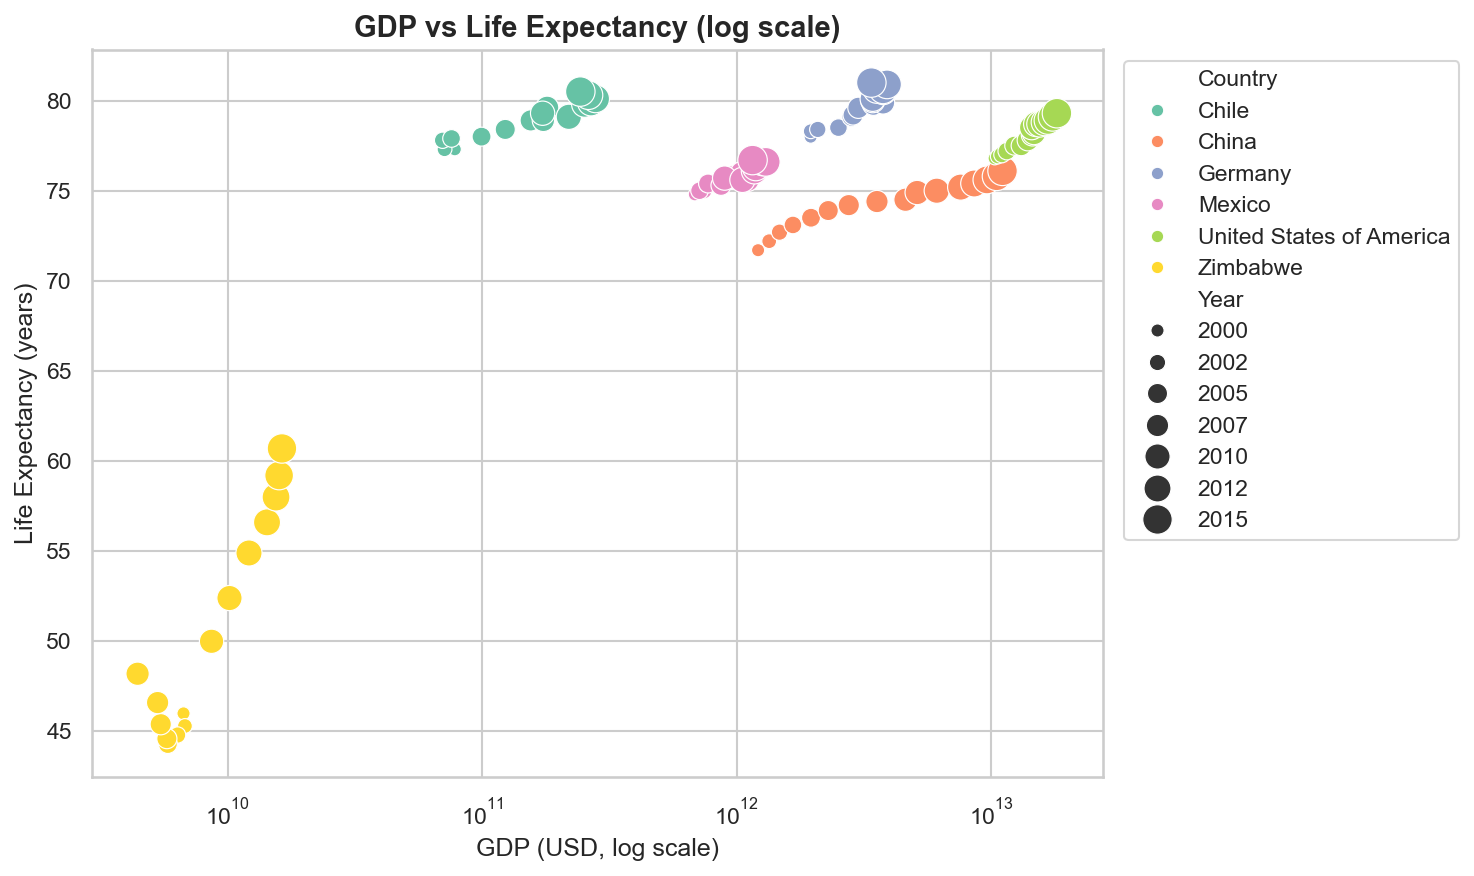

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='gdp', y='life_expectancy',
                hue='Country', size='Year', sizes=(40, 200), ax=ax)
ax.set_xscale('log')
ax.set_title('GDP vs Life Expectancy (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('GDP (USD, log scale)')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/gdp_vs_life_expectancy.png', bbox_inches='tight')
plt.show()

#### Insights Made
- We can see a **positive correlation** between GDP and life expectancy overall.
- When we put the GDP on a logarithmic scale, the relationship is nearly linear.
- Zimbabwe is a clear outlier with a low GDP but a rapid improvement in life expectancy.
- Despite limitations in its economy, Chile still maintains a very high life expectancy.

### 4.4 Average Life Expectancy

=== Average Life Expectancy by Country ===
Country
Zimbabwe                    50.09
China                       74.26
Mexico                      75.72
United States of America    78.06
Chile                       78.94
Germany                     79.66
Name: life_expectancy, dtype: float64



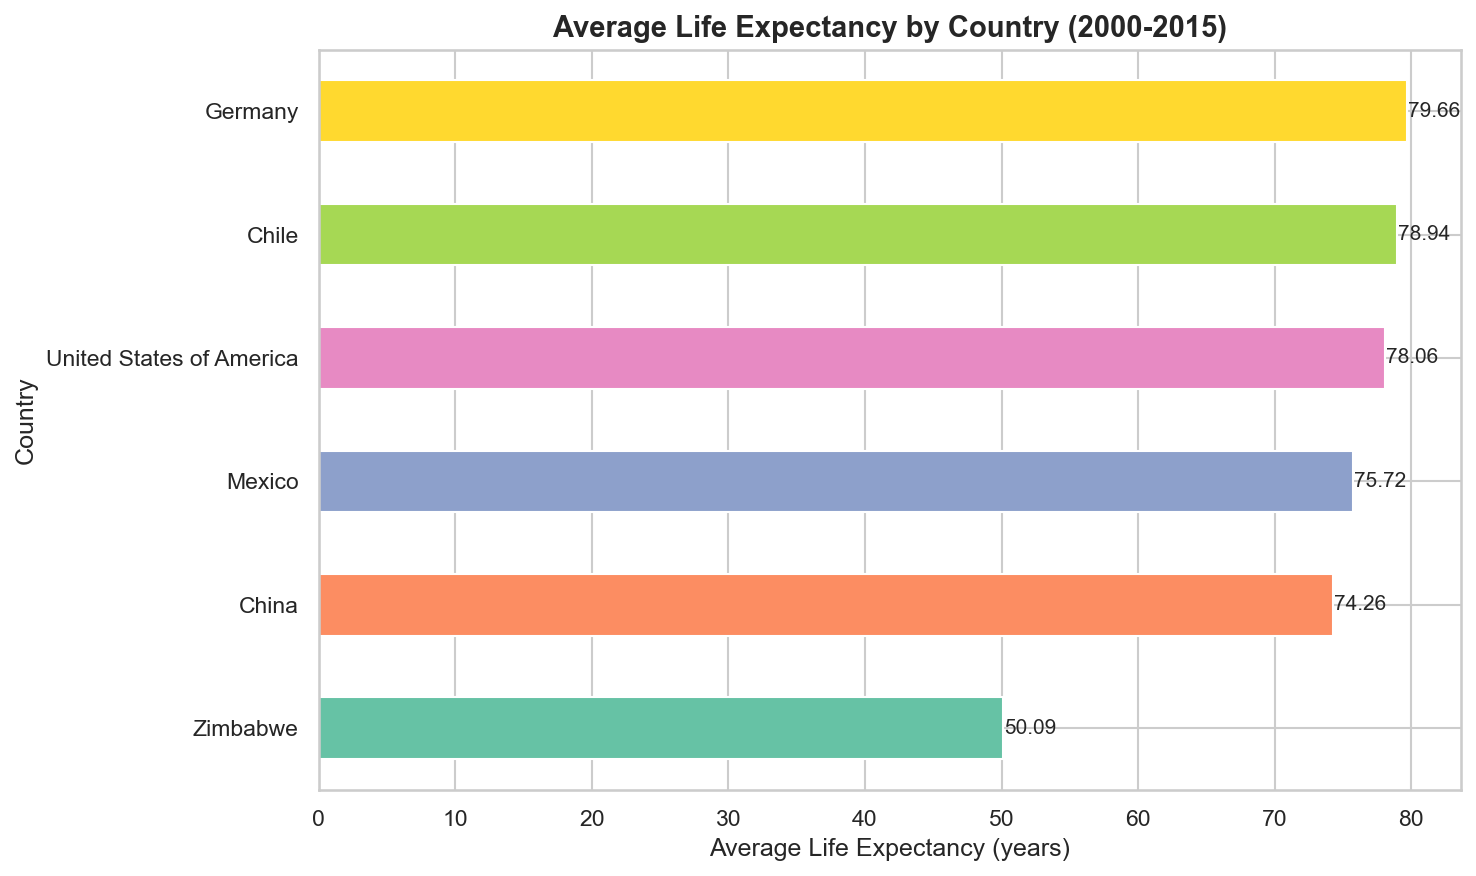

In [20]:
# Calculate averages
avg_le = df.groupby('Country')['life_expectancy'].mean().round(2).sort_values()
print("=== Average Life Expectancy by Country ===")
print(avg_le)
print()

fig, ax = plt.subplots(figsize=(10, 6))
avg_le.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(avg_le)))
ax.set_title('Average Life Expectancy by Country (2000-2015)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Life Expectancy (years)')
ax.set_ylabel('Country')
for i, v in enumerate(avg_le):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/average_life_expectancy.png', bbox_inches='tight')
plt.show()

#### Insights Made
- Germany had the highest life expectancy over the period while Zimbabwe had the lowest.
- The gap between highest and lowest life expectancies is approximately 30 years.

### 4.5 Distribution of Life Expectancy

C:\Users\ashet\AppData\Local\Temp\ipykernel_3688\2757244931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Country', y='life_expectancy',
C:\Users\ashet\AppData\Local\Temp\ipykernel_3688\2757244931.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')


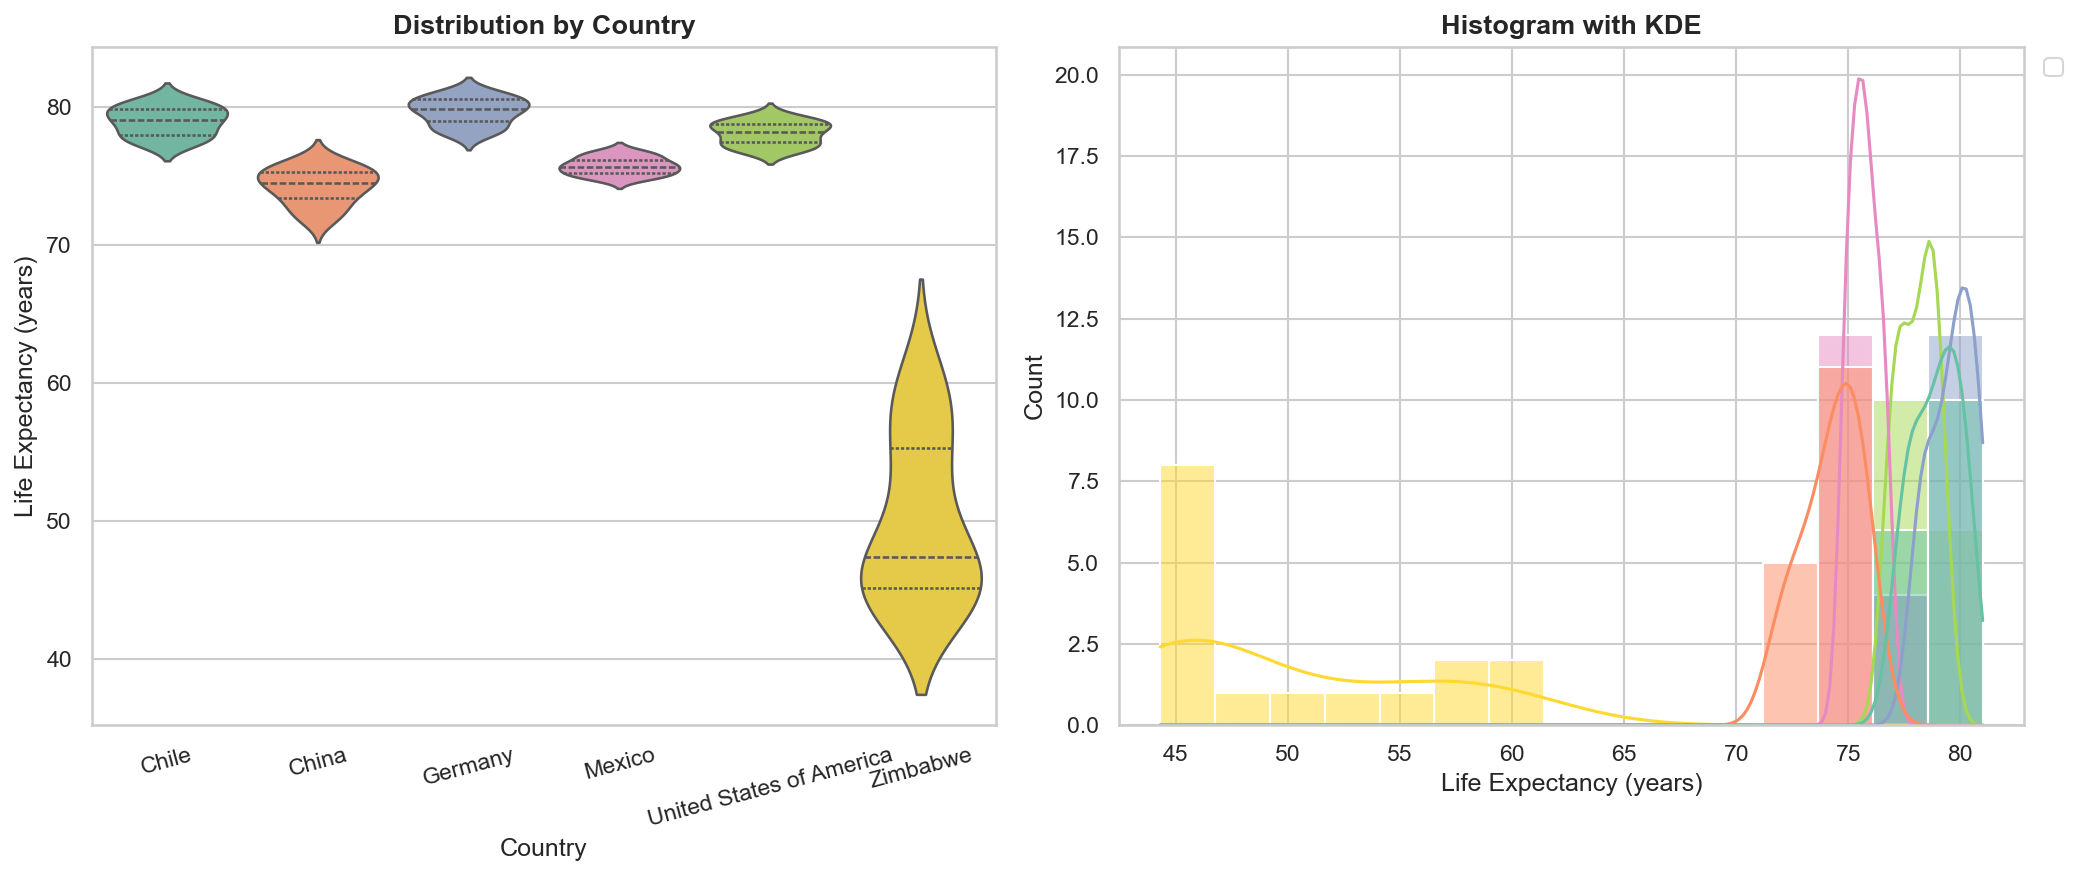

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='Country', y='life_expectancy',
               palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Distribution by Country', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].tick_params(axis='x', rotation=15)

sns.histplot(data=df, x='life_expectancy', hue='Country',
             bins=15, kde=True, ax=axes[1])
axes[1].set_title('Histogram with KDE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('Count')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('images/life_expectancy_distribution.png', bbox_inches='tight')
plt.show()

#### Insights Made
- Zimbabwe has the largest distribution by far, with its range between 46 and 60.7 years old.
- Germany and Chile show tight distributions which show consistently long-living populations with little variation in years.
- Despite its GDP, the USA's distributions is narrower with life expectancies ranging between 77 and 79 years.
- China has a distribution that is slowly shifting to higher life expectancies, demonstrating its improvements in health over the 15-year period.

### 4.6.1 Correlation Heatmap

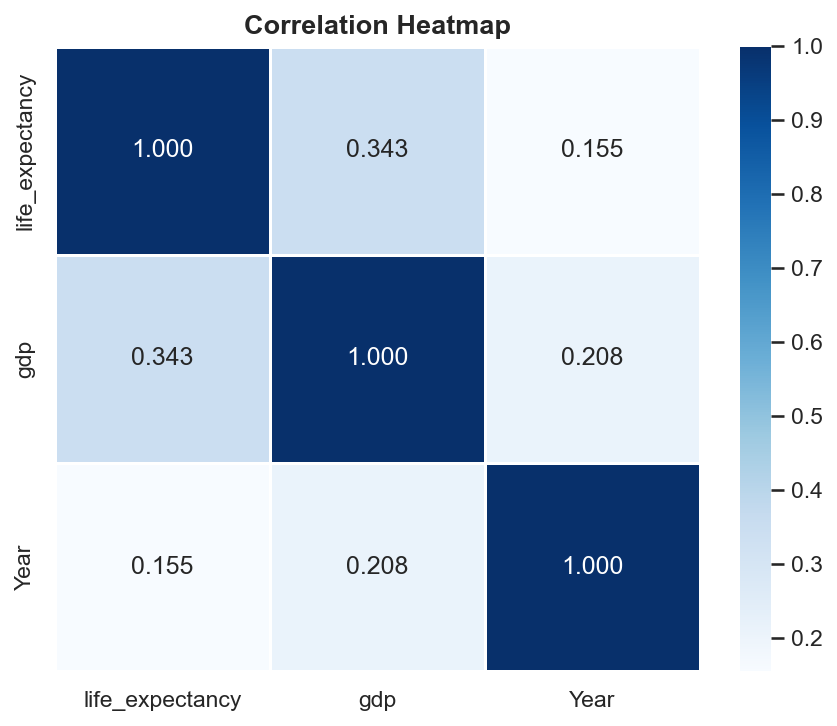

In [22]:
corr = df[['life_expectancy', 'gdp', 'Year']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### Insights Made
- The overall correlation between GDP and life expectancy across all countries and years is **0.343**, which is moderately positive but not as strong as we had anticipated.
- This value may be due to country based differences, notably, Zimbabwe having a low GDP but a significantly improving life expectancy, which pulls the global value down.
- There is a weak positive correlation between year and life expectancy, which confirms a slow but steady improvement over time across the distribution.

### 4.6.2 Per-Country Correlation

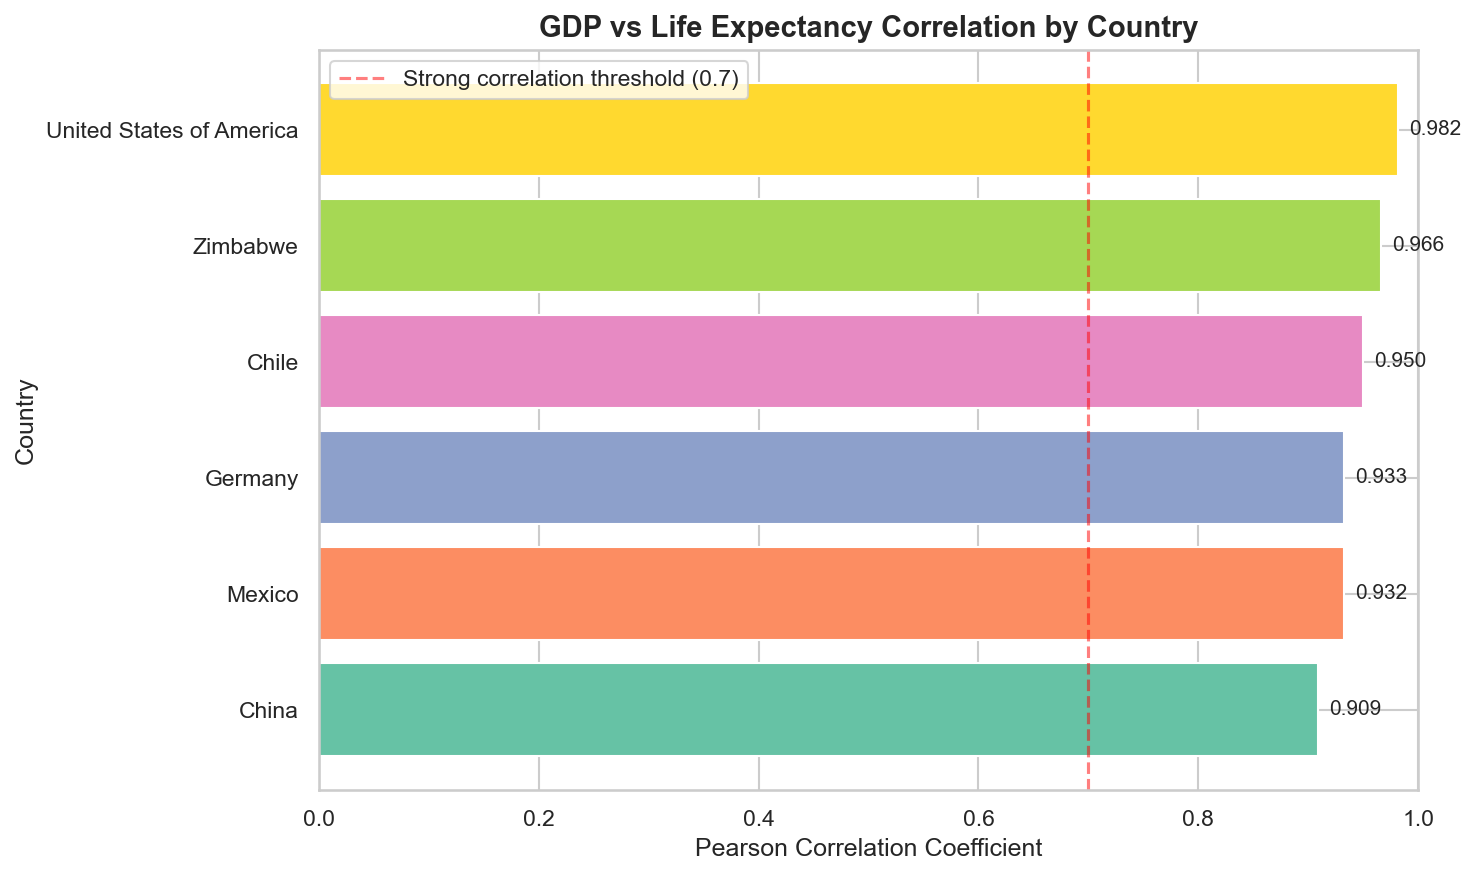

In [23]:
# Calculate correlation per country
country_corr = {}
for country in df['Country'].unique():
    subset = df[df['Country'] == country]
    country_corr[country] = subset['gdp'].corr(subset['life_expectancy'])

corr_df = pd.Series(country_corr).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_df.index, corr_df.values, 
               color=sns.color_palette('Set2', len(corr_df)))
ax.set_xlim(0, 1)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Strong correlation threshold (0.7)')
ax.set_title('GDP vs Life Expectancy Correlation by Country', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Country')
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, corr_df.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/correlation_by_country.png', bbox_inches='tight')
plt.show()

#### Insights Made
- Every country has an **extremely strong positive correlation** (all above 0.9) between GDP and life expectancy.
- The USA has the strongest correlation of 0.982 meaning life expectancy tracks GDP to near perfection over the 15-year tracking period.
- China has the lowest correlation of 0.909, which is still very strong but suggests a slight decoupling between economic and health outcomes.
- Zimbabwe has a notably high correlation between 0.966, showing that even at low GDP levels, health improvements will be noticed.

## 5. Conclusion

### Key Findings

- **GDP and life expectancy are strongly correlated within each country** — every 
  nation in this dataset showed a correlation above 0.90, meaning that as a 
  country's economy grew, its population lived longer.
  
- **The overall cross-country correlation is weaker (0.343)** — this is because 
  GDP alone does not explain the gap *between* countries. Chile outperforms the 
  USA in average life expectancy (78.94 vs 78.06 years) despite having a GDP 
  roughly 80x smaller, pointing to the importance of healthcare system quality 
  and social investment.

- **Zimbabwe is the most striking story in the dataset** — it recorded the lowest 
  GDP throughout the period and started with a life expectancy of just 46.0 years, 
  yet gained 14.7 years by 2015 — the largest improvement of any country. This 
  demonstrates that economic growth is not the only path to better health outcomes.

- **China recorded the most dramatic economic growth**, expanding its GDP nearly 
  10x from $1.2 trillion to $11.1 trillion, accompanied by a consistent 4.4-year 
  rise in life expectancy — the second-largest gain in the dataset.

- **Wealthier nations show diminishing returns** — Germany and the USA started 
  the period with the highest life expectancies and saw the smallest gains (3.0 
  and 2.5 years respectively), suggesting there is a ceiling effect at high 
  levels of development.


### Limitations

- The dataset covers only **six countries** — findings cannot be generalised 
  to the rest of the world without broader data.

- **GDP is a national aggregate** and does not account for income inequality 
  within countries — a high GDP can mask widespread poverty.

- The **2000–2015 window** misses more recent developments including COVID-19, 
  which significantly impacted life expectancy globally.

- Life expectancy is a statistical average and **masks disparities** across 
  gender, ethnicity, and geographic region within each country.

- Several confounding variables are not captured — including **healthcare 
  spending per capita, education levels, and political stability**.

### Further Research

- Expand the analysis to all WHO member nations for a truly global picture.

- Incorporate **healthcare spending per capita** as an additional variable 
  alongside GDP.

- Apply **regression modelling** to quantify how much of the variation in 
  life expectancy can be explained by GDP alone.

- Investigate the specific **public health interventions** behind Zimbabwe's 
  remarkable recovery.

- Extend the time range to include **2015–2023** to capture the impact of 
  COVID-19 on life expectancy across different income levels.

## 6. Facet Grids

### 6.1 Life Expectancy by Country 

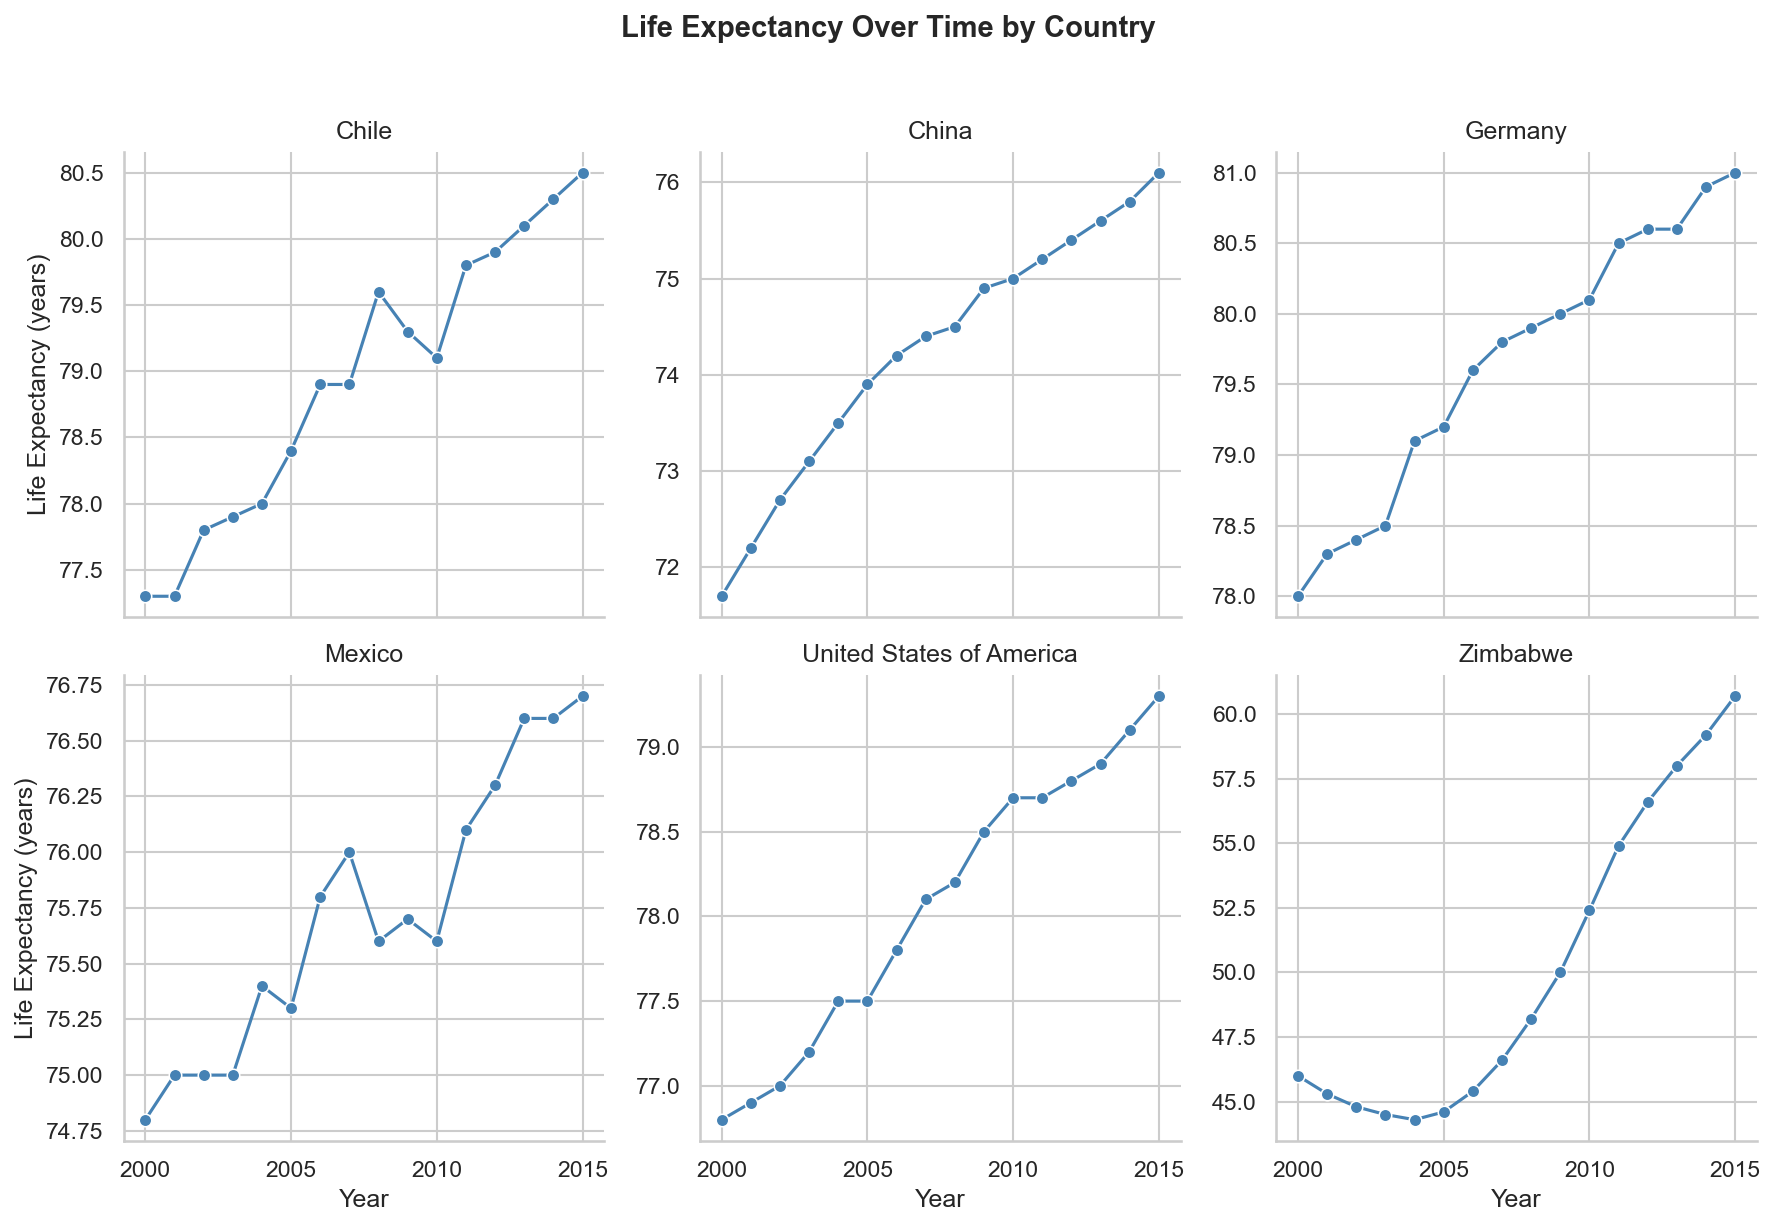

In [24]:
g = sns.FacetGrid(df, col='Country', col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, 'Year', 'life_expectancy', marker='o', color='steelblue')
g.set_axis_labels('Year', 'Life Expectancy (years)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Life Expectancy Over Time by Country', 
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/facet_life_expectancy.png', bbox_inches='tight')
plt.show()

### 6.2 GDP by country

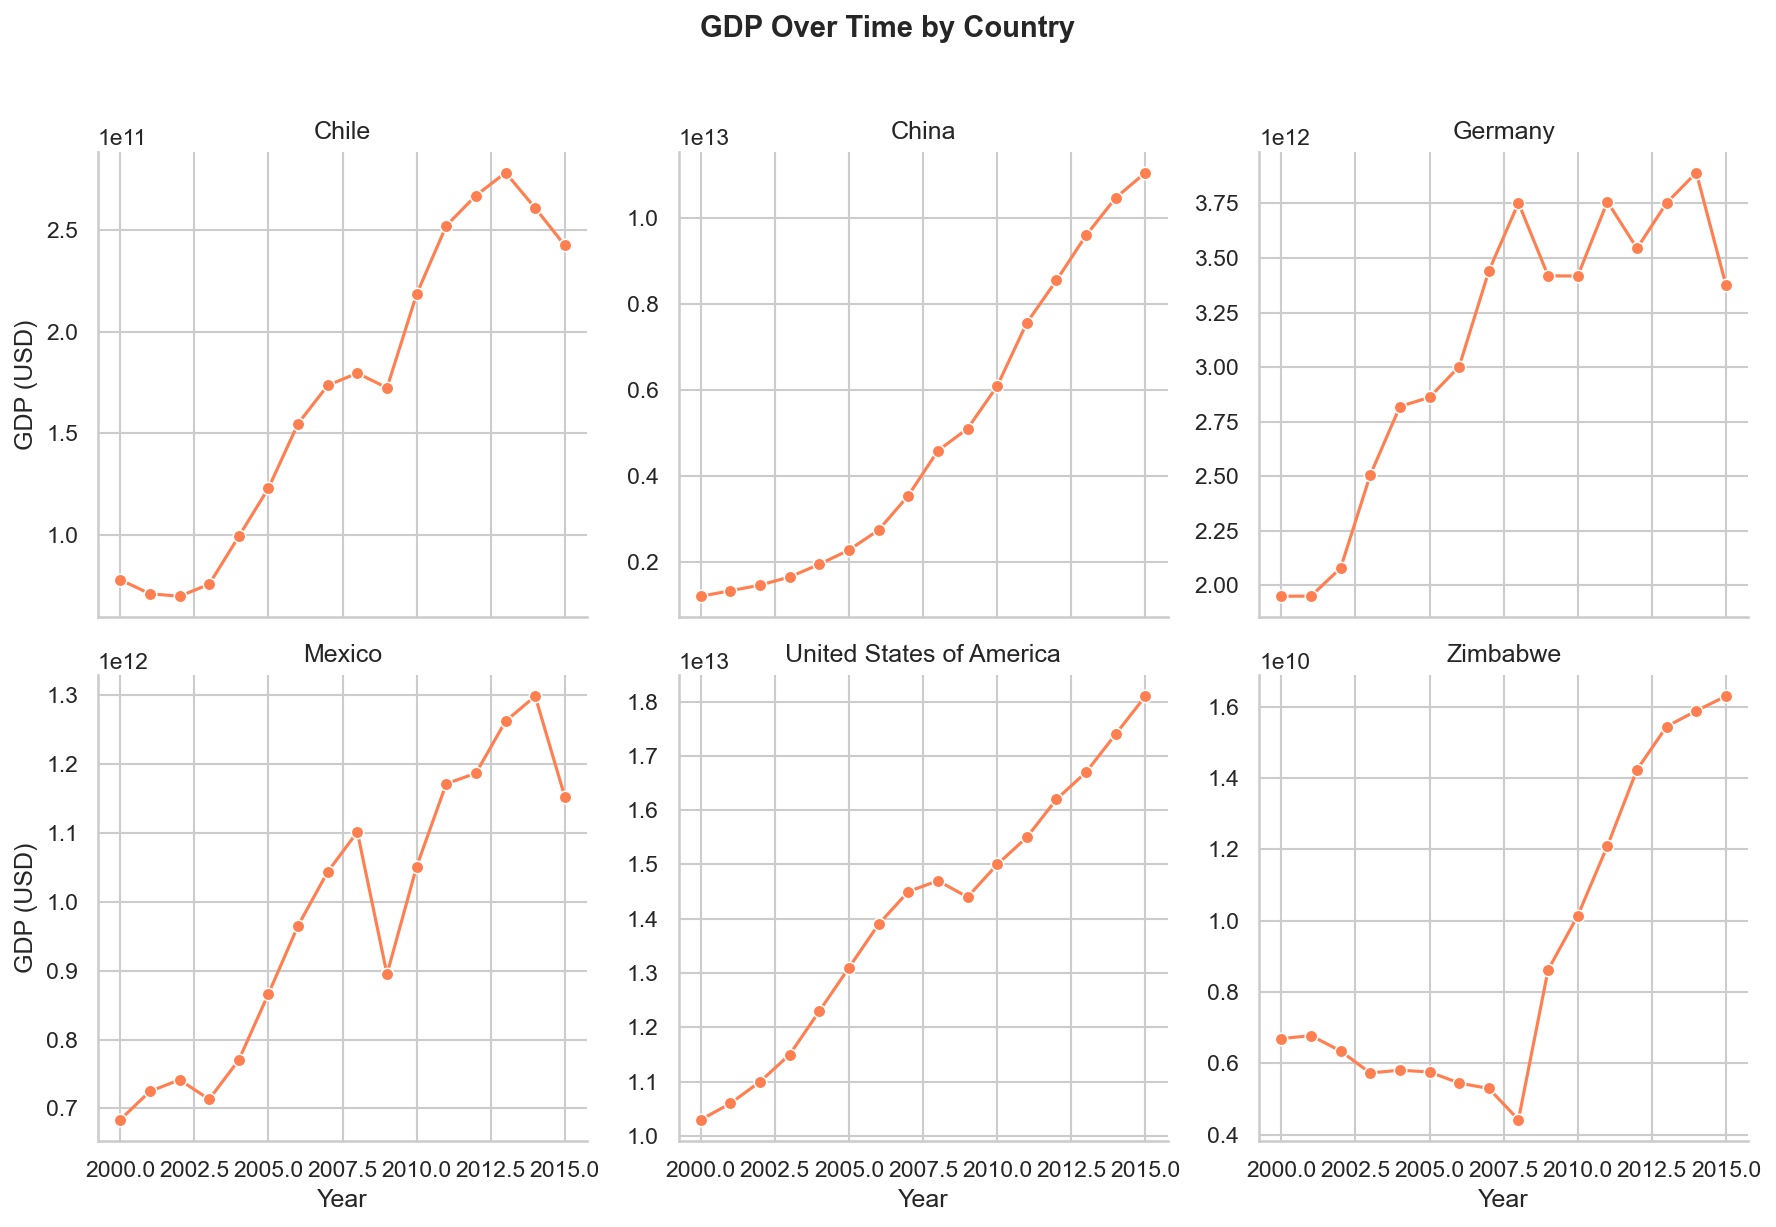

In [25]:
g = sns.FacetGrid(df, col='Country', col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, 'Year', 'gdp', marker='o', color='coral')
g.set_axis_labels('Year', 'GDP (USD)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('GDP Over Time by Country', 
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/facet_gdp.png', bbox_inches='tight')
plt.show()

### 6.3 GDP vs Life Expectancy by Country

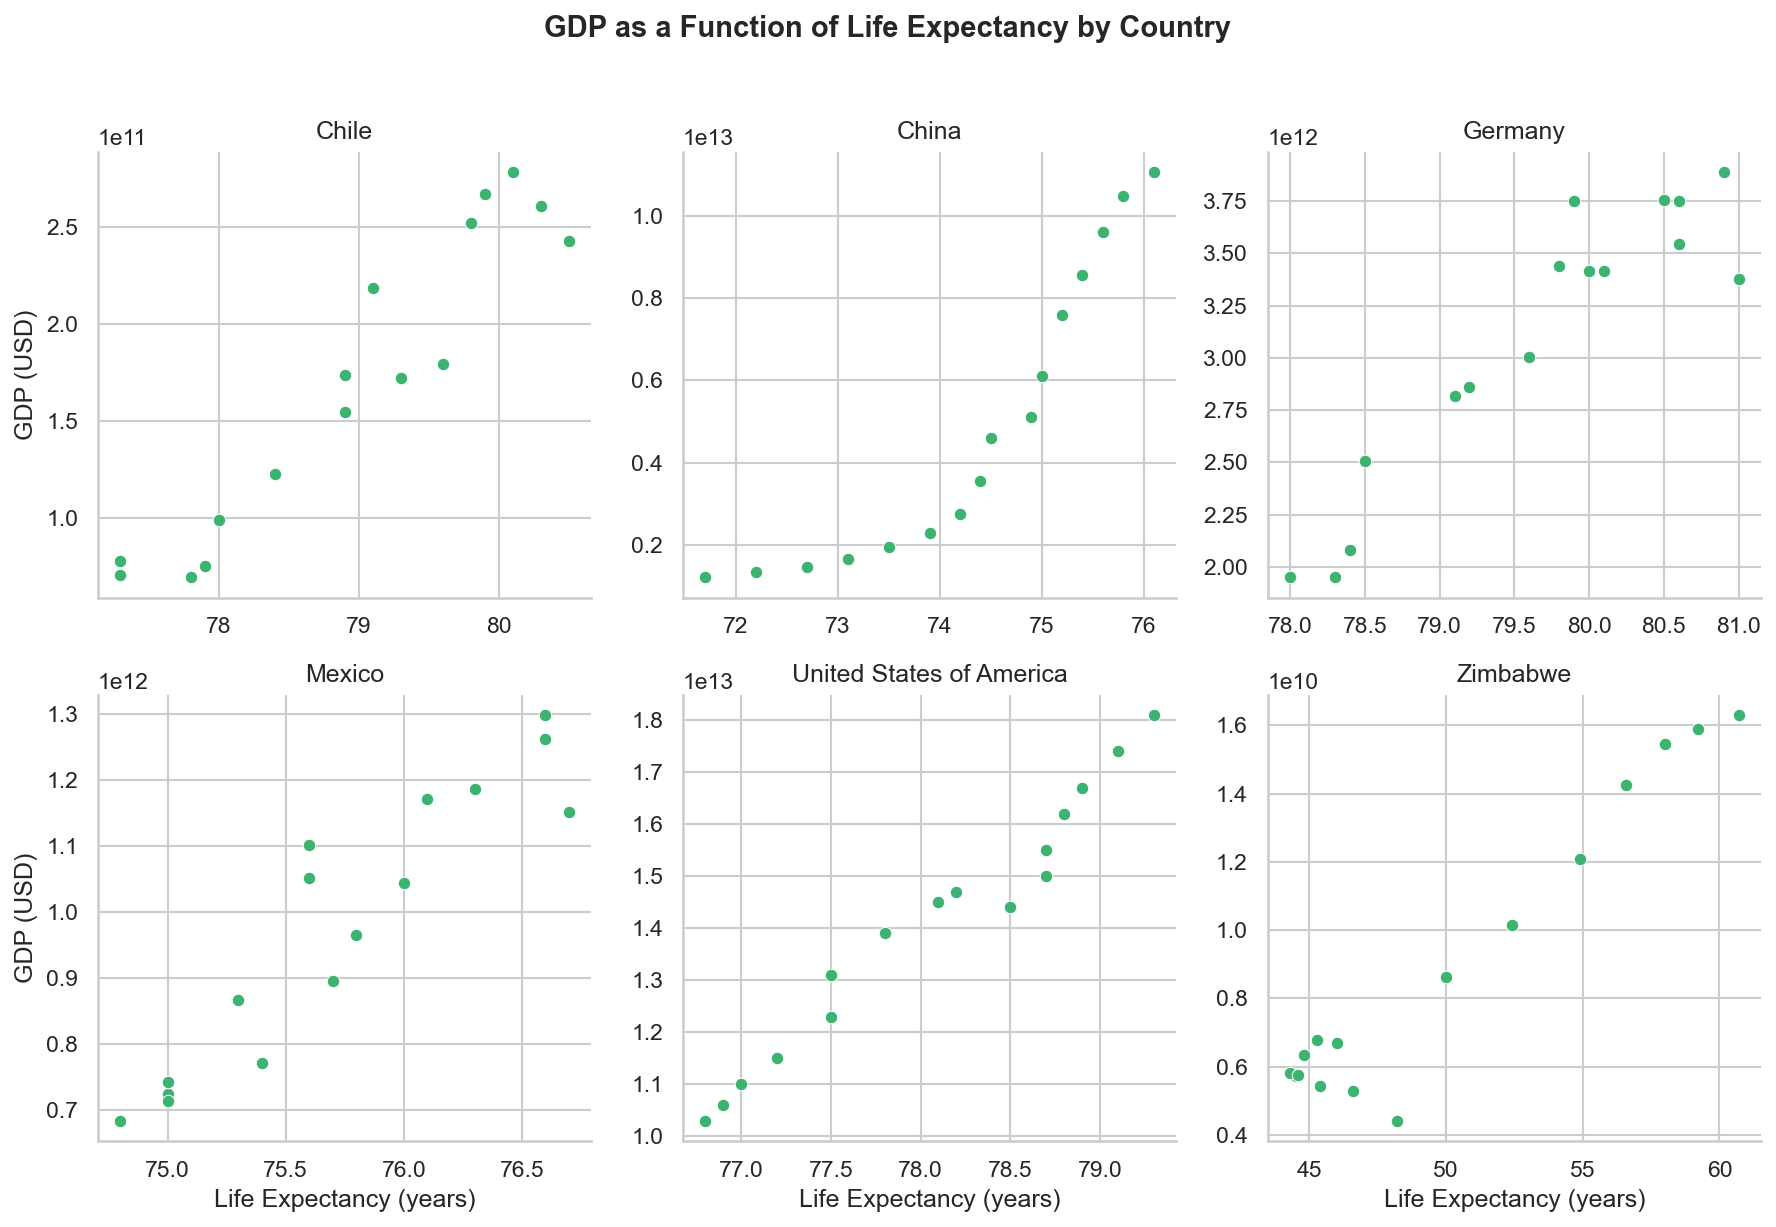

In [26]:
g = sns.FacetGrid(df, col='Country', col_wrap=3, height=4, sharey=False, sharex=False)
g.map(sns.scatterplot, 'life_expectancy', 'gdp', color='mediumseagreen')
g.set_axis_labels('Life Expectancy (years)', 'GDP (USD)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('GDP as a Function of Life Expectancy by Country', 
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/facet_gdp_vs_life_expectancy.png', bbox_inches='tight')
plt.show()